Project: Advanced Machine Learning and MLOps: Tourism Package Prediction

Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

Observation :--

All required libraries for EDA, preprocessing and machine learning are imported.

Load Dataset

In [2]:
df = pd.read_csv("tourism.csv")

print("Shape:", df.shape)

df.head()

Shape: (4128, 21)


,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,...,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,...,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,...,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,...,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,...,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


Observation :--

Dataset contains customer demographics.

Target variable is ProdTaken.

Multiple numerical and categorical columns exist.


Dataset Information

In [3]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                4128 non-null   int64  
 1   CustomerID                4128 non-null   int64  
 2   ProdTaken                 4128 non-null   int64  
 3   Age                       4128 non-null   float64
 4   TypeofContact             4128 non-null   object 
 5   CityTier                  4128 non-null   int64  
 6   DurationOfPitch           4128 non-null   float64
 7   Occupation                4128 non-null   object 
 8   Gender                    4128 non-null   object 
 9   NumberOfPersonVisiting    4128 non-null   int64  
 10  NumberOfFollowups         4128 non-null   float64
 11  ProductPitched            4128 non-null   object 
 12  PreferredPropertyStar     4128 non-null   float64
 13  MaritalStatus             4128 non-null   object 
 14  NumberOf

,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
count,4128.000000,4128.000000,4128.000000,4128.000000,4128,4128.000000,4128.000000,4128,4128,4128.000000,...,4128,4128.000000,4128,4128.0000,4128.000000,4128.000000,4128.000000,4128.000000,4128,4128.000000
unique,NaN,NaN,NaN,NaN,2,NaN,NaN,4,3,NaN,...,5,NaN,4,NaN,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,NaN,NaN,Self Enquiry,NaN,NaN,Salaried,Male,NaN,...,Basic,NaN,Married,NaN,NaN,NaN,NaN,NaN,Executive,NaN
freq,NaN,NaN,NaN,NaN,2918,NaN,NaN,1999,2463,NaN,...,1615,NaN,1990,NaN,NaN,NaN,NaN,NaN,1615,NaN
mean,2527.763808,202527.763808,0.193072,37.231831,NaN,1.663275,15.584787,NaN,NaN,2.949370,...,NaN,3.578488,NaN,3.2953,0.295300,3.060804,0.612161,1.223595,NaN,23178.464147
std,1409.439133,1409.439133,0.394757,9.174521,NaN,0.920640,8.398142,NaN,NaN,0.718818,...,NaN,0.795031,NaN,1.8563,0.456233,1.363064,0.487317,0.852685,NaN,4506.614622
min,0.000000,200000.000000,0.000000,18.000000,NaN,1.000000,5.000000,NaN,NaN,1.000000,...,NaN,3.000000,NaN,1.0000,0.000000,1.000000,0.000000,0.000000,NaN,1000.000000
25%,1320.750000,201320.750000,0.000000,31.000000,NaN,1.000000,9.000000,NaN,NaN,2.000000,...,NaN,3.000000,NaN,2.0000,0.000000,2.000000,0.000000,1.000000,NaN,20751.000000
50%,2603.500000,202603.500000,0.000000,36.000000,NaN,1.000000,14.000000,NaN,NaN,3.000000,...,NaN,3.000000,NaN,3.0000,0.000000,3.000000,1.000000,1.000000,NaN,22418.000000
75%,3748.250000,203748.250000,0.000000,43.000000,NaN,3.000000,20.000000,NaN,NaN,3.000000,...,NaN,4.000000,NaN,4.0000,1.000000,4.000000,1.000000,2.000000,NaN,25301.000000


Observation :--

It helps us Identify:


Numerical variables

Categorical variables

Missing values

Data types

Missing Value Analysis

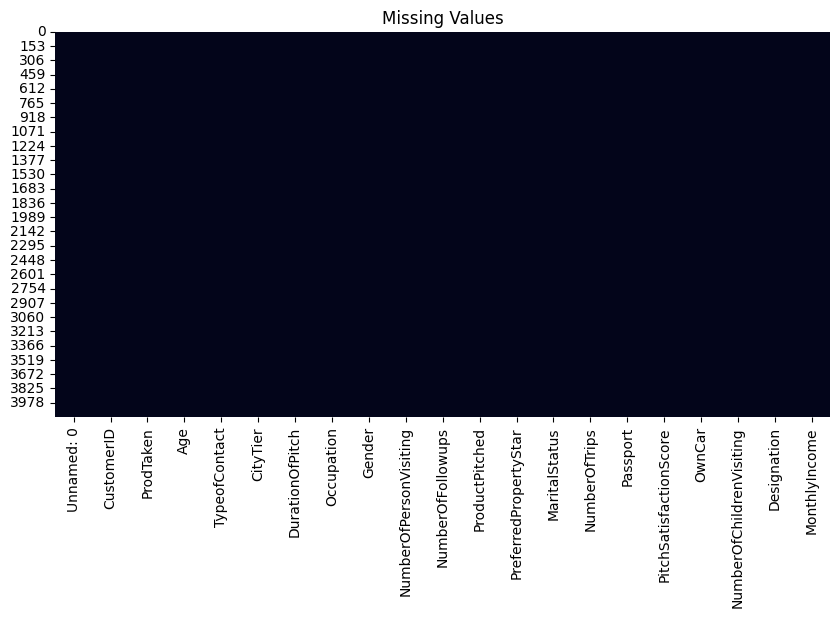

In [4]:
df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

**Observation :--**

Missing values likely exist in:

Age

NumberOfFollowups

PreferredPropertyStar

DurationOfPitch

MonthlyIncome

**Recommendation**

Missing values should be imputed rather than dropping records.

**Duplicate Records**

In [5]:
duplicates = df.duplicated().sum()

print("Duplicate Rows =", duplicates)

Duplicate Rows = 0


**Observation :-- **

No Duplicate rows

**Remove Unnecessary Columns**

In [6]:
df.drop(columns=["CustomerID"], inplace=True)

**Observation**

CustomerID is unique identifier only.

**Target Variable Analysis**

In [7]:
df['ProdTaken'].value_counts()

,count
ProdTaken,
0,3331
1,797


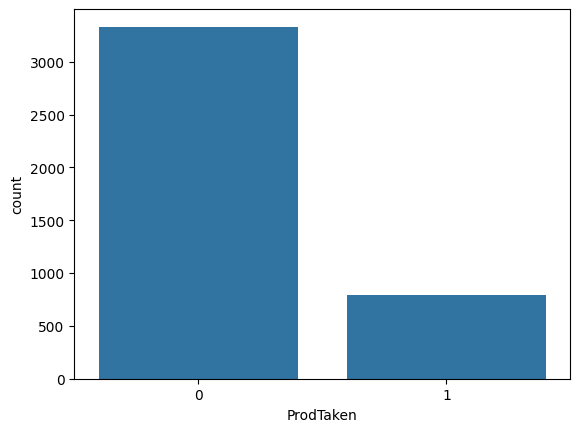

In [8]:
sns.countplot(x='ProdTaken', data=df)
plt.show()

**Observation**

Check class balance.

**Age Distribution**

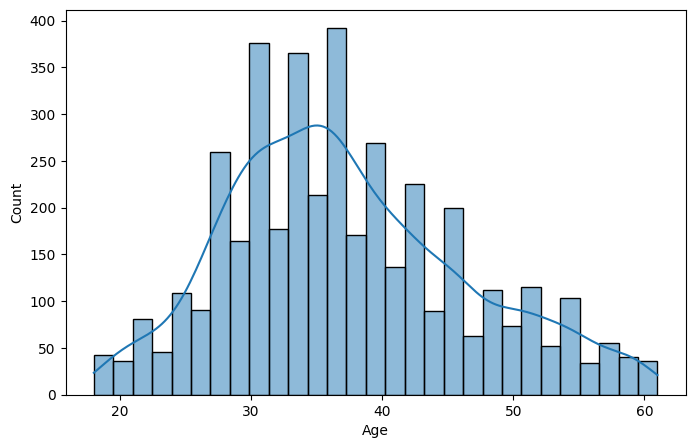

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.show()

**Observation**

Detect age groups contributing most to purchases.

**Recommendation**

Design age-specific marketing campaigns.

**Monthly Income Analysis**

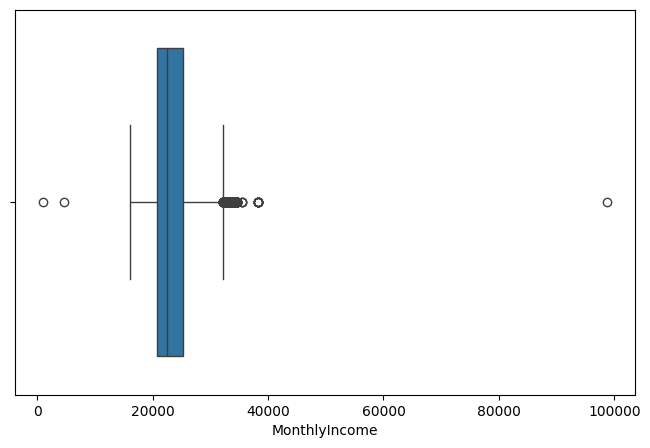

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['MonthlyIncome'])
plt.show()

**Observation**

Income contains potential outliers.

**Recommendation**

Premium packages can target higher-income customers.

**Occupation Analysis**

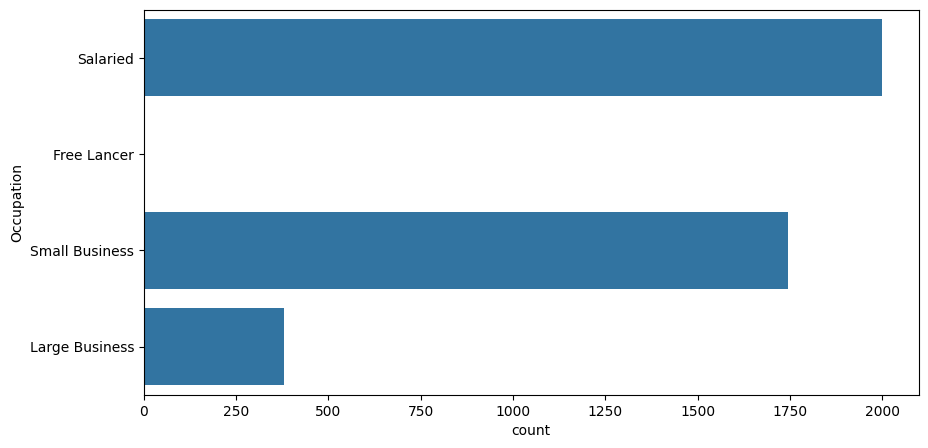

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(y='Occupation', data=df)
plt.show()

**Observation**

Identify dominant occupation categories.

**Recommendation**

Create occupation-focused campaigns.

**Gender Analysis**

In [12]:
pd.crosstab(df['Gender'],df['ProdTaken'])

ProdTaken,0,1
Gender,,
Fe Male,130,25
Female,1236,274
Male,1965,498


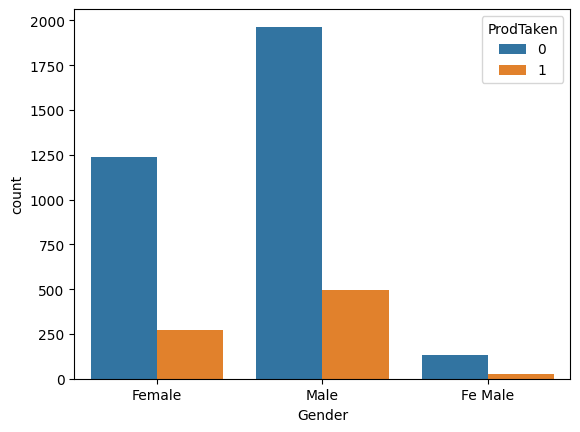

In [13]:
sns.countplot(x='Gender', hue='ProdTaken', data=df)
plt.show()

**Observation**

Compare purchase behavior by gender.

**Recommendation**

Customize communication approaches.

**Marital Status Analysis**

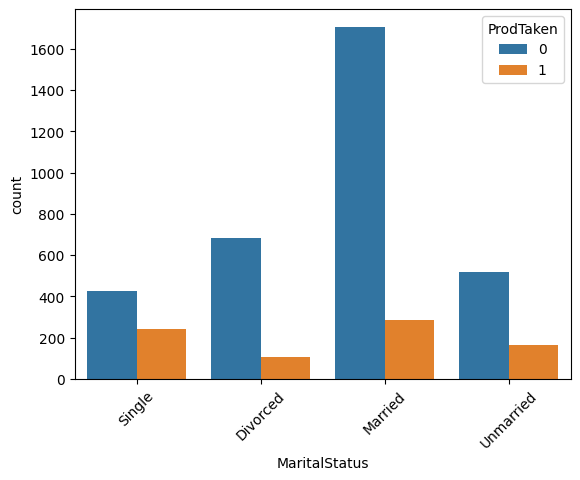

In [14]:
sns.countplot(x='MaritalStatus',
              hue='ProdTaken',
              data=df)
plt.xticks(rotation=45)
plt.show()

**Observation**

Marital status may influence tourism package purchases.

**Recommendation**

Family-oriented marketing may be effective.

**Passport Analysis**

In [15]:
pd.crosstab(df['Passport'], df['ProdTaken'])

ProdTaken,0,1
Passport,,
0,2549,360
1,782,437


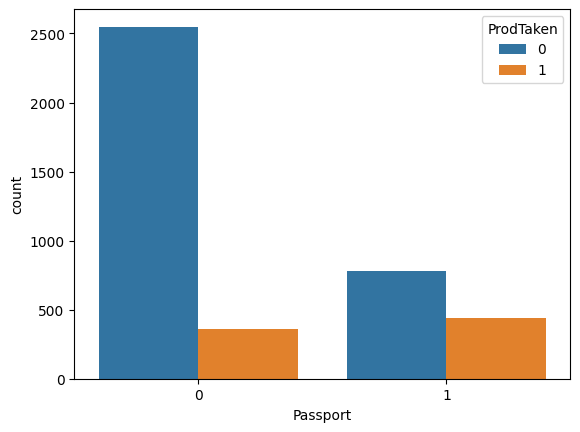

In [16]:
sns.countplot(x='Passport', hue='ProdTaken', data=df)
plt.show()

**Observation**

Passport holders often show higher travel tendency.

**Recommendation**

Target international travel products toward passport holders.

**Number of Trips Analysis**

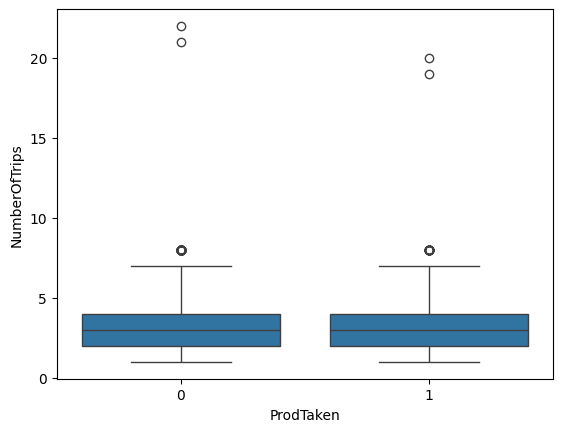

In [17]:
sns.boxplot(x='ProdTaken',
            y='NumberOfTrips',
            data=df)
plt.show()

**Observation**

Frequent travelers may show stronger purchase intent.

**Recommendation**

Use NumberOfTrips as an important feature.

**Product Pitched Analysis**

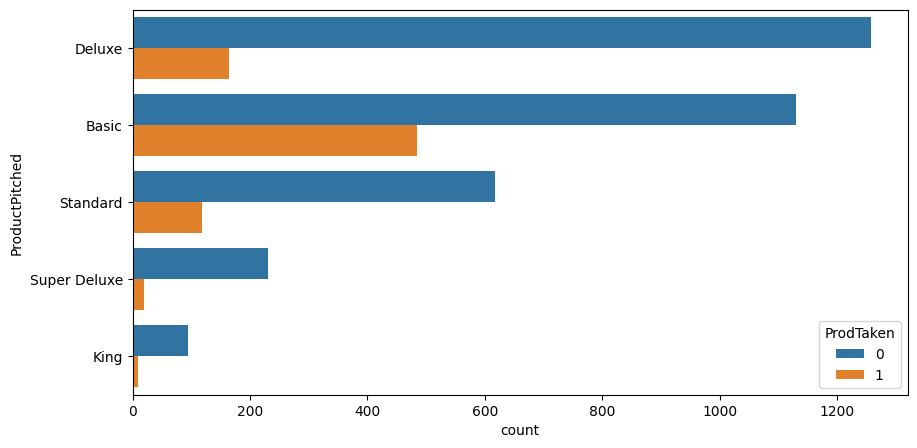

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(y='ProductPitched',
              hue='ProdTaken',
              data=df)
plt.show()

**Observation**

Certain products generate better conversions.

**Recommendation**

Focus sales efforts on successful package categories.

**Correlation Heatmap**

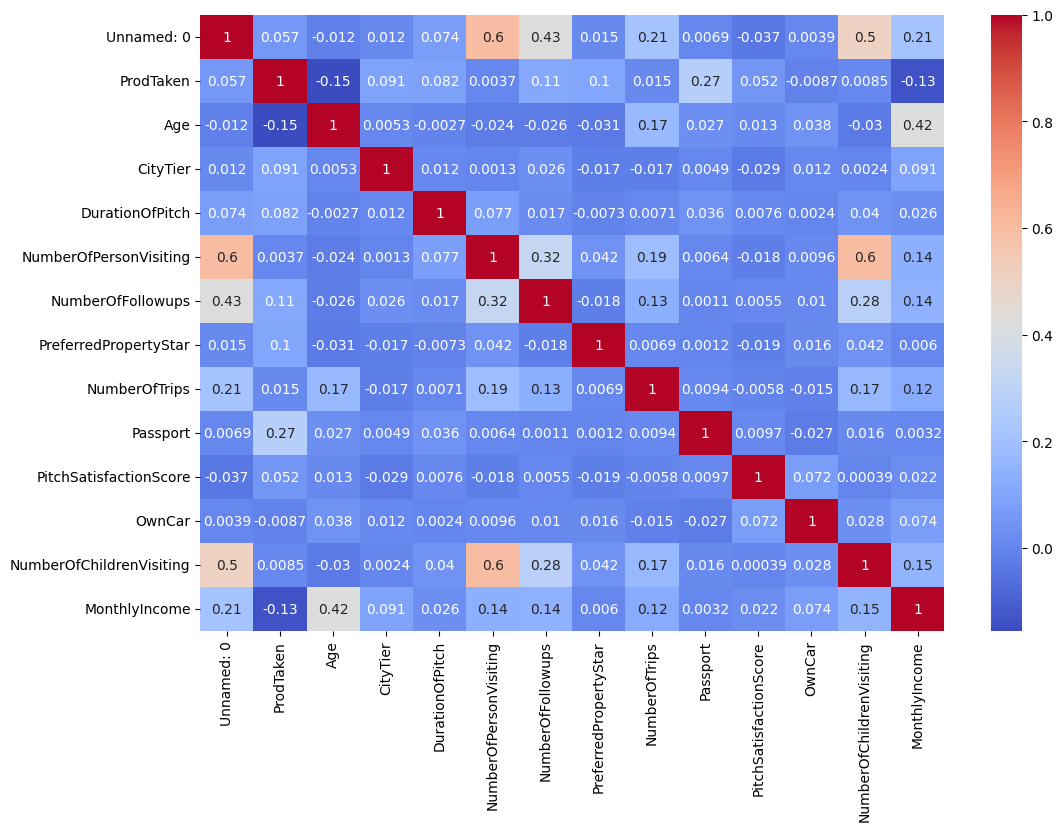

In [19]:
num_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(num_cols.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

**Observation**

Identify strongest relationships.

**Recommendation**

Highly correlated variables may influence predictions.

**Outlier Detection**

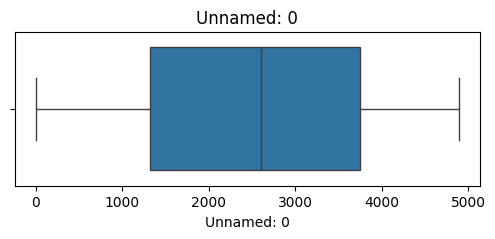

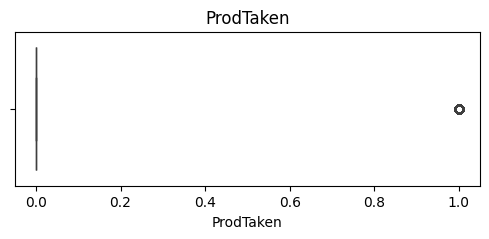

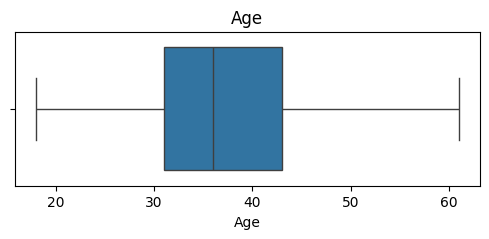

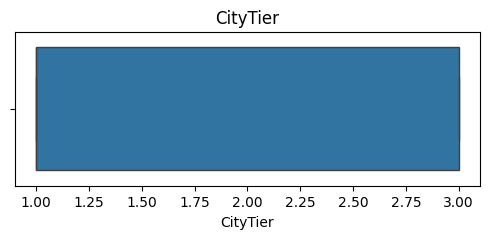

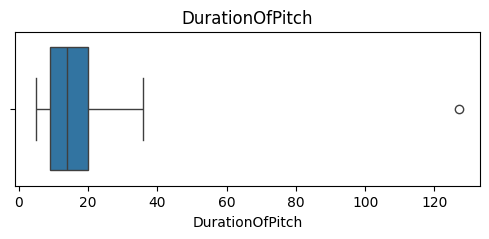

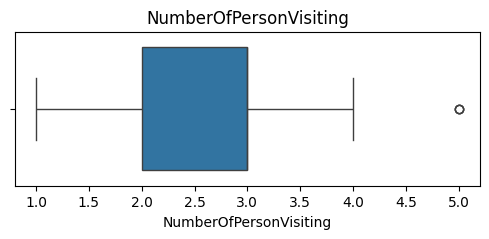

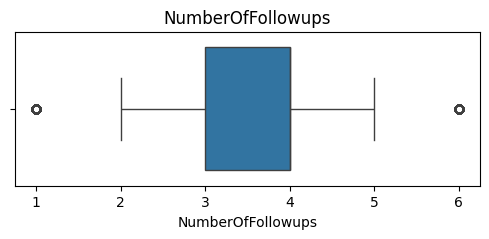

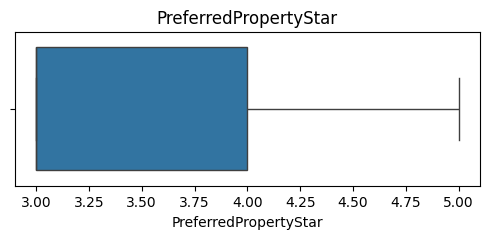

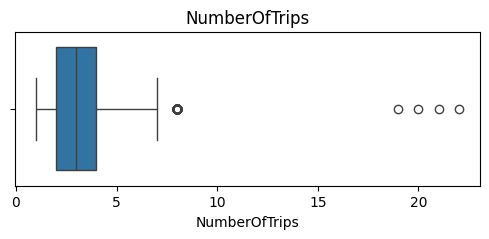

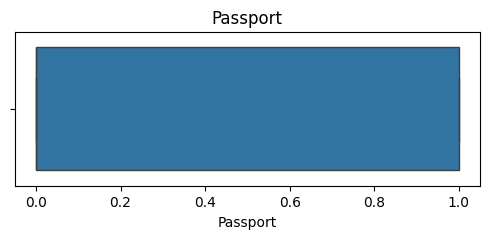

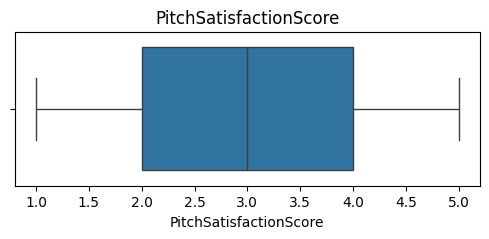

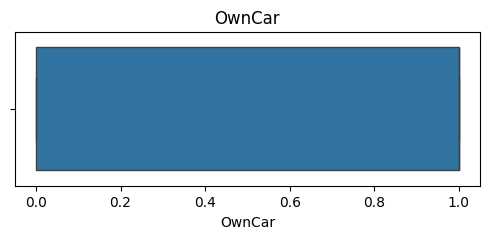

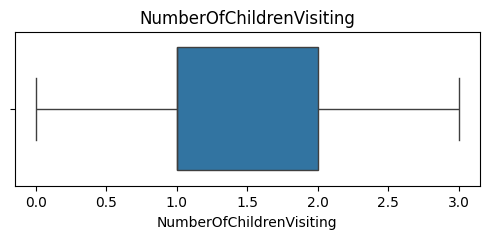

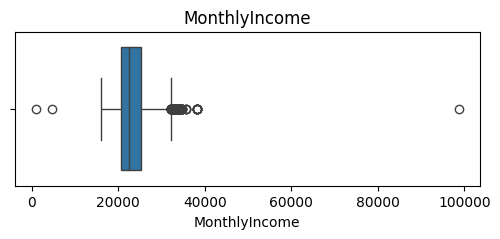

In [20]:
for col in num_cols.columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

**Observation**

Outliers visible in:


Income

Trips

Duration

**Recommendation**

Capping may improve model stability.

# ***Purchase Rate by Occupation***

In [21]:
occupation_analysis = pd.crosstab(
    df['Occupation'],
    df['ProdTaken'],
    normalize='index'
) * 100

occupation_analysis

ProdTaken,0,1
Occupation,,
Free Lancer,0.000000,100.000000
Large Business,70.866142,29.133858
Salaried,82.041021,17.958979
Small Business,81.386025,18.613975


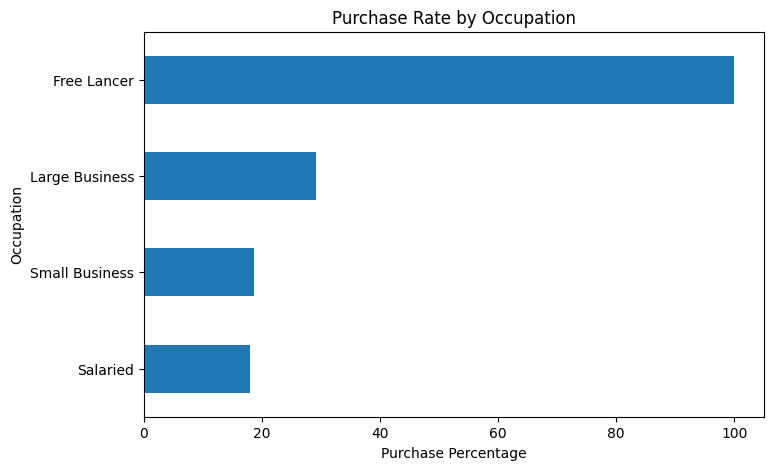

In [22]:
occupation_analysis[1].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Purchase Rate by Occupation')
plt.xlabel('Purchase Percentage')
plt.show()

**Observation**

Some occupations may purchase packages significantly more often than others.

**Recommendation**

Target marketing campaigns toward high-converting occupations.

# ***Purchase Rate by Designation***

In [23]:
designation_analysis = pd.crosstab(
    df['Designation'],
    df['ProdTaken'],
    normalize='index'
)*100

designation_analysis

ProdTaken,0,1
Designation,,
AVP,92.400000,7.600000
Executive,69.969040,30.030960
Manager,88.396624,11.603376
Senior Manager,83.853460,16.146540
VP,91.346154,8.653846


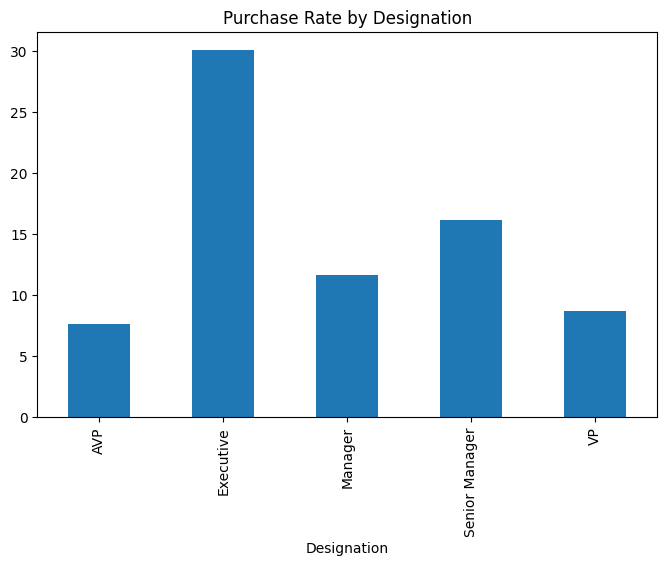

In [24]:
designation_analysis[1].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Purchase Rate by Designation')
plt.show()

**Observation**

Higher designations may have greater purchasing power.

**Recommendation**

Create premium package campaigns for senior executives.

# ***Passport vs Purchase***

In [25]:
passport_analysis = pd.crosstab(
    df['Passport'],
    df['ProdTaken'],
    normalize='index'
) * 100

passport_analysis

ProdTaken,0,1
Passport,,
0,87.624613,12.375387
1,64.150943,35.849057


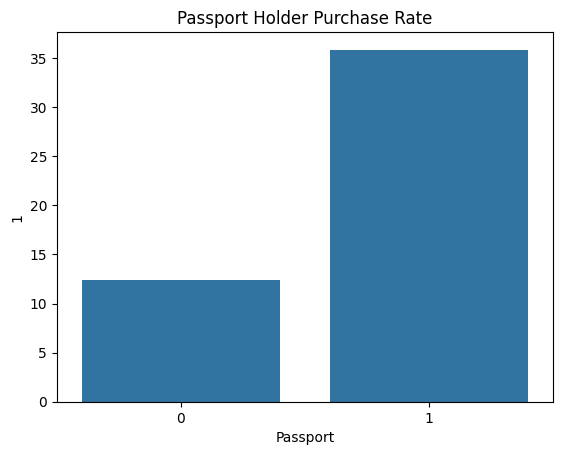

In [26]:
sns.barplot(
    x=passport_analysis.index,
    y=passport_analysis[1]
)

plt.title("Passport Holder Purchase Rate")
plt.show()

**Observation**

Passport holders often exhibit stronger travel intent.

**Recommendation**

This should be one of the most valuable predictive features.

# ***Satisfaction Score vs Purchase***

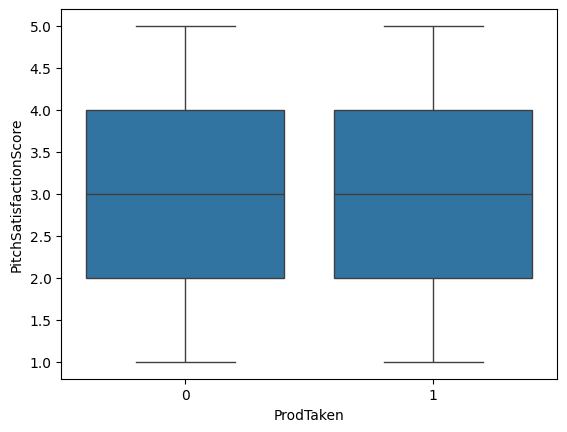

In [27]:
sns.boxplot(
    x='ProdTaken',
    y='PitchSatisfactionScore',
    data=df
)

plt.show()

**Observation**

Customers with higher satisfaction scores may convert more frequently.

**Recommendation**

Improve pitch quality and salesperson training.

# ***Followups vs Purchase***

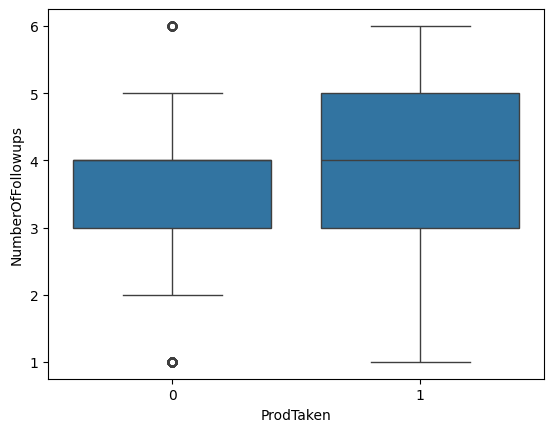

In [28]:
sns.boxplot(
    x='ProdTaken',
    y='NumberOfFollowups',
    data=df
)

plt.show()

**Observation**

Follow-ups may directly influence conversion.

**Recommendation**

Develop automated follow-up campaigns.

# ***Duration of Pitch***

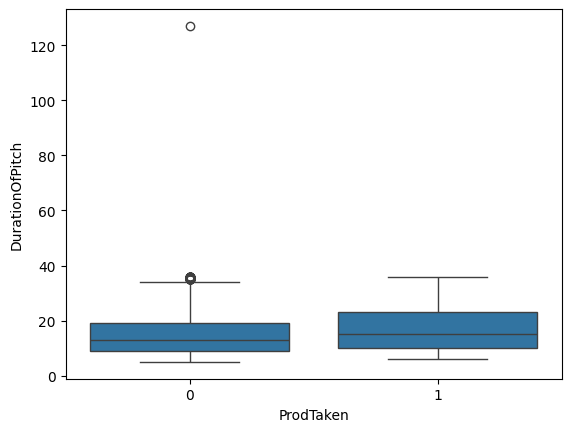

In [29]:
sns.boxplot(
    x='ProdTaken',
    y='DurationOfPitch',
    data=df
)

plt.show()

**Observation**

Very short or very long pitches may impact conversion differently.

# ***City Tier Analysis***

In [30]:
city_analysis = pd.crosstab(
    df['CityTier'],
    df['ProdTaken'],
    normalize='index'
)*100

city_analysis

ProdTaken,0,1
CityTier,,
1,83.457804,16.542196
2,73.456790,26.543210
3,75.854037,24.145963


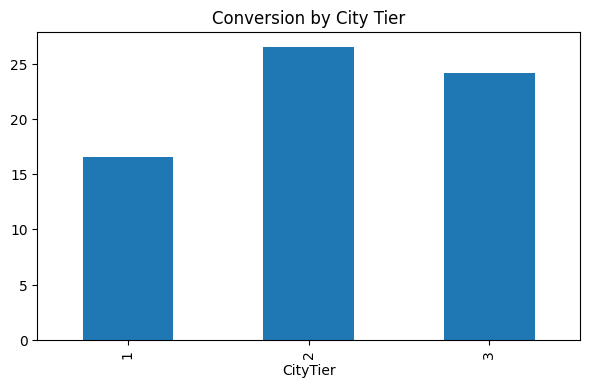

In [31]:
city_analysis[1].plot(
    kind='bar',
    figsize=(7,4)
)

plt.title('Conversion by City Tier')
plt.show()

**Observation**

Purchase patterns may differ across city tiers.

**Recommendation**

Customize marketing budgets by geography.

# ***Income Segmentation***

In [32]:
df['IncomeGroup'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

pd.crosstab(
    df['IncomeGroup'],
    df['ProdTaken'],
    normalize='index'
)*100

ProdTaken,0,1
IncomeGroup,,
Low,73.475315,26.524685
Medium,77.303589,22.696411
High,85.575992,14.424008
Very High,86.420951,13.579049


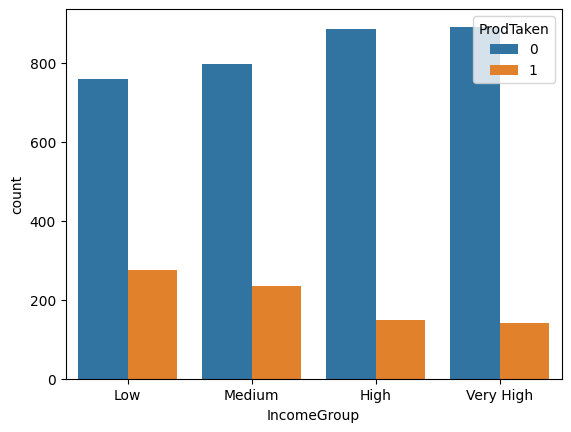

In [33]:
sns.countplot(
    x='IncomeGroup',
    hue='ProdTaken',
    data=df
)

plt.show()

**Observation**

Income may be strongly related to package purchase decisions.

**Recommendation**

Create different offerings for each income segment.

# ***Product Pitched vs Conversion***

In [34]:
product_analysis = pd.crosstab(
    df['ProductPitched'],
    df['ProdTaken'],
    normalize='index'
) * 100

product_analysis

ProdTaken,0,1
ProductPitched,,
Basic,69.969040,30.030960
Deluxe,88.396624,11.603376
King,91.346154,8.653846
Standard,83.853460,16.146540
Super Deluxe,92.400000,7.600000


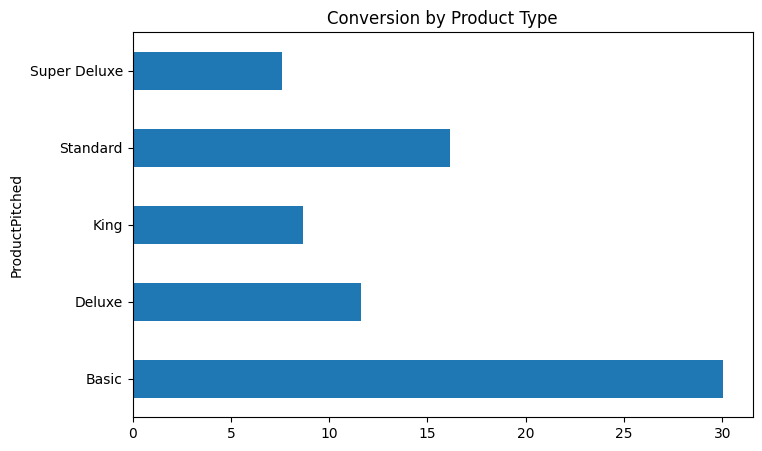

In [35]:
product_analysis[1].plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Conversion by Product Type')
plt.show()

**Observation**

Certain products generate higher conversions.

# ***Numerical Feature Relationship with Target***

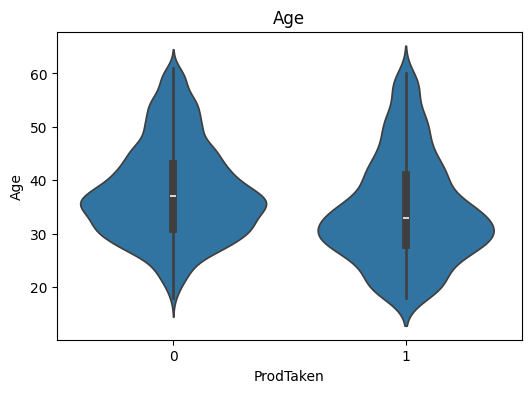

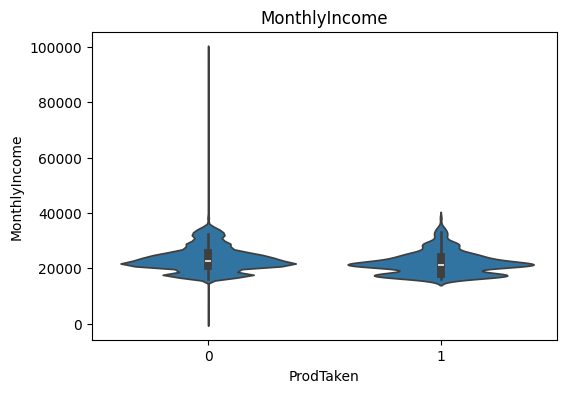

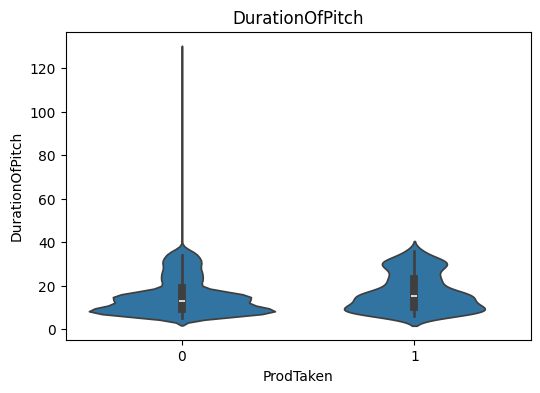

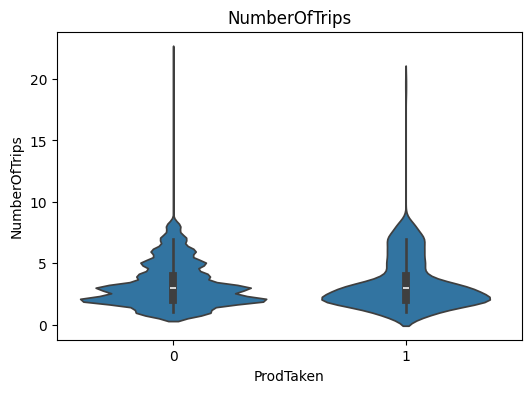

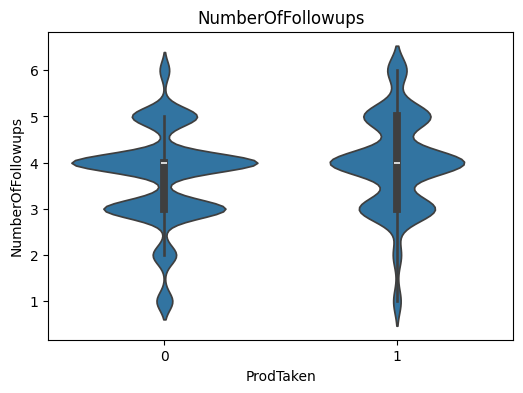

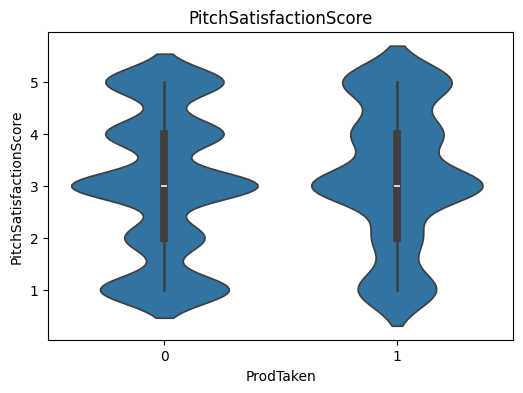

In [36]:
numeric_cols = [
    'Age',
    'MonthlyIncome',
    'DurationOfPitch',
    'NumberOfTrips',
    'NumberOfFollowups',
    'PitchSatisfactionScore'
]

for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.violinplot(
        x='ProdTaken',
        y=col,
        data=df
    )

    plt.title(col)

    plt.show()

**Observation**

Provides a much deeper understanding of how purchasers differ from non-purchasers.

**Recommendation**

Very useful to discuss feature importance later.

# ***Data Cleaning***

In [38]:
df['Gender'] = df['Gender'].replace(
    {'Fe Male':'Female'}
)

**Observation**

Inconsistent categories exist.

# ***Train-Test Split***

In [39]:
X = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ***Save Train and Test Data***

In [40]:
train_data = pd.concat([X_train,y_train],axis=1)
test_data = pd.concat([X_test,y_test],axis=1)

train_data.to_csv('train.csv',index=False)
test_data.to_csv('test.csv',index=False)

**Observation**

Training and testing datasets stored separately.

# ***Feature Engineering Pipeline***

In [41]:
num_features = X.select_dtypes(include=np.number).columns

cat_features = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='median'))
            ]),
            num_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore'))
            ]),
            cat_features
        )
    ]
)

# ***Random Forest Model + Hyperparameter Tuning***

In [42]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42
    ))
])

In [43]:
param_grid = {
    'model__n_estimators':[100,200],
    'model__max_depth':[5,10,None],
    'model__min_samples_split':[2,5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         Index(['Unnamed: 0', 'Age', 'CityTier', 'DurationOfPitch',
       'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'Num...
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='roc_auc')

# ***Best Parameters***

In [44]:
print(grid.best_params_)

{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


**Observation**

Grid Search identifies best hyper-parameters.

***Model Evaluation***

In [45]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

prob = best_model.predict_proba(X_test)[:,1]

print("Accuracy:",
      accuracy_score(y_test,pred))

print("ROC-AUC:",
      roc_auc_score(y_test,prob))

Accuracy: 0.8958837772397095
ROC-AUC: 0.9601284263528613


In [46]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94       667
           1       0.91      0.51      0.65       159

    accuracy                           0.90       826
   macro avg       0.90      0.75      0.80       826
weighted avg       0.90      0.90      0.88       826



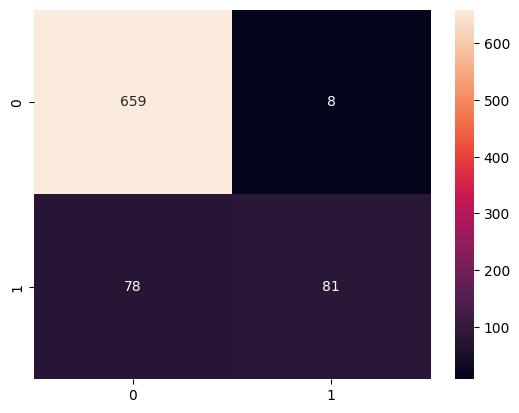

In [47]:
sns.heatmap(confusion_matrix(y_test,pred),
            annot=True,
            fmt='d')

plt.show()

**Observation**

Evaluate:

Accuracy

Precision

Recall

F1 Score

ROC-AUC

**Recommendation**

ROC-AUC should be highlighted because business objective is customer targeting.

# ***Final Business Insights & Recommendations***
**Key Insights**

Passport holders show stronger propensity to purchase.

NumberOfTrips is a significant behavioral indicator.

Monthly Income influences package selection.

ProductPitched impacts conversion rates.

Occupation and Designation help identify premium customers.

Customer engagement variables are valuable predictors.



**Business Recommendations**

Prioritize customers with passports and higher travel frequency.


Focus marketing budget on segments with historically higher conversion.

Personalize package recommendations using customer demographics.

Increase follow-ups for high-probability prospects.

Deploy model through Hugging Face for real-time lead scoring.

Automate retraining using GitHub Actions CI/CD workflow.

Continuously monitor model performance for drift.

In [51]:
from huggingface_hub import login

login()

In [52]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '69db98339232e513cba3a4ac', 'name': 'amitjannu', 'fullname': 'Jannu', 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1785542400, 'isPro': False, 'avatarUrl': '/avatars/db55bf141c887b2cd6a06c223cc70f79.svg', 'orgs': [], 'auth': {'type': 'oauth', 'expiresAt': '2026-08-10T17:31:36.000Z'}}


# ***Data Registration***

In [53]:
from datasets import Dataset

hf_dataset = Dataset.from_pandas(df)
hf_dataset.push_to_hub("amitjannu/tourism_dataset")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 97.2kB / 97.2kB            

CommitInfo(commit_url='https://huggingface.co/datasets/amitjannu/tourism_dataset/commit/4c77a6e19c361e488599cb1b8dd1255b6cea68bf', commit_message='Upload dataset', commit_description='', oid='4c77a6e19c361e488599cb1b8dd1255b6cea68bf', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/amitjannu/tourism_dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='amitjannu/tourism_dataset'), pr_revision=None, pr_num=None)

In [54]:
from huggingface_hub import create_repo

create_repo(
    repo_id="amitjannu/tourism-dataset",
    repo_type="dataset",
    exist_ok=True
)

RepoUrl('https://huggingface.co/datasets/amitjannu/tourism-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='amitjannu/tourism-dataset')

In [56]:
from datasets import load_dataset

dataset = load_dataset(
    "amitjannu/tourism-dataset"
)

df = dataset["train"].to_pandas()

df.head()

tourism.csv:   0%|          | 0.00/477k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4128 [00:00<?, ? examples/s]

,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,...,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,...,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,...,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,...,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,...,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


**Create train.csv and test.csv**

In [57]:
train_data.to_csv(
    'train.csv',
    index=False
)

test_data.to_csv(
    'test.csv',
    index=False
)

In [58]:
import joblib

joblib.dump(
    best_model,
    "best_model.pkl"
)

['best_model.pkl']

# ***Model Registration***

In [55]:
from huggingface_hub import HfApi